In [96]:
import numpy as np
import pandas as pd
import collections
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
import random
import warnings
import collections
import os

# Set professional visualization context
sns.set_theme(style="whitegrid")
sns.set_context("talk")
sns.set_context("paper", font_scale=2)

In [97]:
current_path = os.getcwd()
print(f"📍 Current Directory: {current_path}")

📍 Current Directory: D:\Downloads\ipynb


In [98]:
# ==========================================
# 1. CORE UTILITIES: Mana & Tag Parsing
# ==========================================
def clean_tags(tag_input):
    """Converts CSV string lists like "['draw', 'ramp']" into Python lists."""
    if pd.isna(tag_input) or tag_input in ["", "[]", "nan"]:
        return []
    if isinstance(tag_input, list):
        return tag_input
    try:
        # Handles standard stringified Python lists
        return ast.literal_eval(str(tag_input))
    except (ValueError, SyntaxError):
        # Fallback for comma-separated values without brackets
        return [t.strip().lower() for t in str(tag_input).replace('[','').replace(']','').split(',') if t.strip()]

class Card:
    def __init__(self, name, mana_str, m_tags, g_tags, type_line, card_draw=0):
        self.name = name
        self.type_line = str(type_line).lower()
        self.produces = self._parse_mana_symbols(mana_str)
        
        # Combine manual and generated tags
        raw_tags = clean_tags(m_tags) + clean_tags(g_tags)
        
        # NUMERIC DRAW LOGIC: Automatically tag cards with card_draw numbers > 0
        self.draw_value = float(card_draw) if pd.notna(card_draw) else 0
        if self.draw_value > 0:
            raw_tags.append('draw')
            
        self.tags = list(set([t.lower().strip() for t in raw_tags]))
        
    def _parse_mana_symbols(self, s):
        """Converts symbols like {W}{U} or {C}{C} into a production vector."""
        v = [0]*6 # [White, Blue, Black, Red, Green, Colorless]
        if pd.isna(s) or s == "0" or s == "": return v
        s = str(s)
        if "{Any}" in s: return [1, 1, 1, 1, 1, 0]
        mapping = {'W':0, 'U':1, 'B':2, 'R':3, 'G':4, 'C':5}
        for char, idx in mapping.items():
            v[idx] = s.count(f"{{{char}}}")
        return v

In [99]:
# ==========================================
# 2. UPDATED DECK SIMULATOR
# ==========================================
class DeckSimulator:
    def __init__(self, csv_path):
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"Could not find {csv_path}. Please check your filename.")
            
        self.df = pd.read_csv(csv_path)
        self.color_names = ['White', 'Blue', 'Black', 'Red', 'Green', 'Colorless']
        
        # Initialize the deck
        self.full_deck = [
            Card(r['name'], 
                 r.get('mana_production', "0"), 
                 r.get('manual_tags', []), 
                 r.get('generated_effect_tags', []),
                 r.get('type_line', ""), 
                 card_draw=r.get('card_draw', 0)) 
            for _, r in self.df.iterrows()
        ]
        
        # --- AUTO-DISCOVERY MENUS ---
        self.manual_menu = sorted(list(set(t for r in self.df.get('manual_tags', pd.Series([])).apply(clean_tags) for t in r)))
        self.generated_menu = sorted(list(set(t for r in self.df.get('generated_effect_tags', pd.Series([])).apply(clean_tags) for t in r)))
        # Combined list of all tags currently in the deck
        self.all_tags = sorted(list(set(tag for card in self.full_deck for tag in card.tags)))

    def deck_stats(self):
        """Prints a quick breakdown of what was loaded."""
        print(f"✅ Deck Loaded: {len(self.full_deck)} cards.")
        mana_sources = sum(1 for c in self.full_deck if sum(c.produces) > 0)
        print(f"📊 Mana Sources Found: {mana_sources}")
        draw_cards = sum(1 for c in self.full_deck if 'draw' in c.tags)
        print(f"🃏 Cards with 'draw' (Numeric or Tagged): {draw_cards}")

    def run_simulation(self, iterations=5000, max_turns=12, tags_to_track=None):
        if not tags_to_track: tags_to_track = []
        draw_results = collections.defaultdict(lambda: collections.defaultdict(int))
        color_stats = {t: np.zeros(6) for t in range(1, max_turns + 1)}

        for _ in range(iterations):
            deck = list(self.full_deck); random.shuffle(deck)
            hand, library = deck[:7], deck[7:]
            board, found_tags = [], set()
            
            for t in range(1, max_turns + 1):
                if library: hand.append(library.pop(0))
                
                # Tag tracking (Cumulative discovery)
                current_hand_tags = [tag for card in hand for tag in card.tags]
                for target in tags_to_track:
                    if target.lower() in current_hand_tags and target not in found_tags:
                        draw_results[target][t] += 1
                        found_tags.add(target)
                
                # Mana progression (Simplified: play 1 source if available)
                for i, card in enumerate(hand):
                    if sum(card.produces) > 0:
                        board.append(hand.pop(i))
                        break 
                
                # Mana Normalization (Sol Ring = 2.0, Dual Land = 1.0 total)
                turn_pool = np.zeros(6)
                for s in board:
                    active_indices = [idx for idx, val in enumerate(s.produces) if val > 0]
                    if active_indices:
                        total_source_value = sum(s.produces)
                        share = total_source_value / len(active_indices)
                        for idx in active_indices:
                            turn_pool[idx] += share
                color_stats[t] += turn_pool

        # Normalize across iterations
        mana_df = pd.DataFrame(color_stats).T / iterations
        mana_df.columns = self.color_names
        
        # Calculate Probabilities
        draw_probs = {tag: {t: sum(draw_results[tag][i] for i in range(1, t+1))/iterations 
                            for t in range(1, max_turns+1)} for tag in tags_to_track}
        
        return {'mana_df': mana_df, 'draw_probs': draw_probs}

In [100]:
# ==========================================
# 3. VISUALIZATION FUNCTIONS
# ==========================================
def plot_results(results):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,20))
    
    # --- 1. EXPECTED MANA SOURCES ---
    mana_df = results['mana_df']
    mtg_colors = {'White':'#F8F2D8','Blue':'#0E68AB','Black':'#2c3e50',
                  'Red':'#D3202A','Green':'#00733E','Colorless':'#90ADBB'}
    
    mana_df.plot(kind='bar', stacked=True, ax=ax1,
                 color=[mtg_colors[c] for c in mana_df.columns], 
                 edgecolor='black', width=0.8, alpha=0.9)
    
    # Add Total Labels on top
    totals = mana_df.sum(axis=1)
    for i, total in enumerate(totals):
        ax1.text(i, total + 0.1, f'{total:.1f}', ha='center', va='bottom', weight='bold', fontsize=14)

    ax1.set_title("Average Mana Capacity by Turn", fontsize=18, weight='bold', pad=20)
    ax1.set_ylabel("Expected Total Mana Points", fontsize=14)
    ax1.set_ylim(0, max(totals) + 2)
    ax1.legend(title="Color Breakdown", loc='upper left', bbox_to_anchor=(1, 1))

    # --- 2. CUMULATIVE ODDS ---
    for tag, curves in results['draw_probs'].items():
        sorted_turns = sorted(curves.keys())
        probs = [curves[t] * 100 for t in sorted_turns]
        ax2.plot(sorted_turns, probs, label=tag.replace('_',' ').capitalize(), marker='o', linewidth=3, markersize=8)
    
    ax2.set_title("Odds of Finding Key Tags (Cumulative)", fontsize=18, weight='bold', pad=20)
    ax2.set_ylabel("% Probability", fontsize=14)
    ax2.set_xlabel("Turn Number", fontsize=14)
    ax2.set_ylim(0, 105)
    ax2.axhline(50, color='grey', linestyle='--', alpha=0.5) # 50% threshold line
    ax2.legend(frameon=True, shadow=True, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

In [101]:
# 1. LOAD YOUR DECK
SIM_FILE = "mtg_final_classified_deck.csv" # Change this to your filename
sim = DeckSimulator(SIM_FILE)

# 2. RUN DIAGNOSTIC (Verify numeric draw works)
sim.deck_stats()

# 3. TAG DISCOVERY MENU
# Look at these lists and decide what to put in 'tags_to_graph'
print("\n--- 📝 MANUAL TAGS FOUND ---")
print(sim.manual_menu)
print("\n--- 🤖 GENERATED TAGS FOUND ---")
print(sim.generated_menu)

✅ Deck Loaded: 100 cards.
📊 Mana Sources Found: 45
🃏 Cards with 'draw' (Numeric or Tagged): 6

--- 📝 MANUAL TAGS FOUND ---
['additional-cost', 'bottom-of-library', 'card-draw', 'counters', 'deathtouch', 'discard', 'double-strike', 'draw-step', 'enchant', 'end-step', 'enter-tapped', 'first-strike', 'flash', 'flying', 'goad', 'graveyard', 'haste', 'hexproof', 'indestructible', 'legendary', 'lifelink', 'mill', 'protection', 'sacrifice', 'scry', 'shuffle', 'tap-ability', 'token', 'tutor', 'upkeep', 'vigilance']

--- 🤖 GENERATED TAGS FOUND ---
['Adventurer', 'Aggressive', 'Ancestral Power', 'Angel Archetype', 'Artifact', 'Assassin Archetype', 'Attack-Block', 'Aura', 'Card Draw', 'Combat Celebrant', 'Combat-Enhancer', 'Combat-less', 'Combo', 'Command Tower', 'Commander', 'Constructed', 'Control', 'Convergence', 'Counterspell', 'Creature', 'Creature Swap', 'Cycling', 'DamageLand', 'Deathtouch Archetype', 'Disruption', 'Dungeon Delver', 'Dungeon Rush', 'Elemental Archetype', 'Embereth', 'Encha

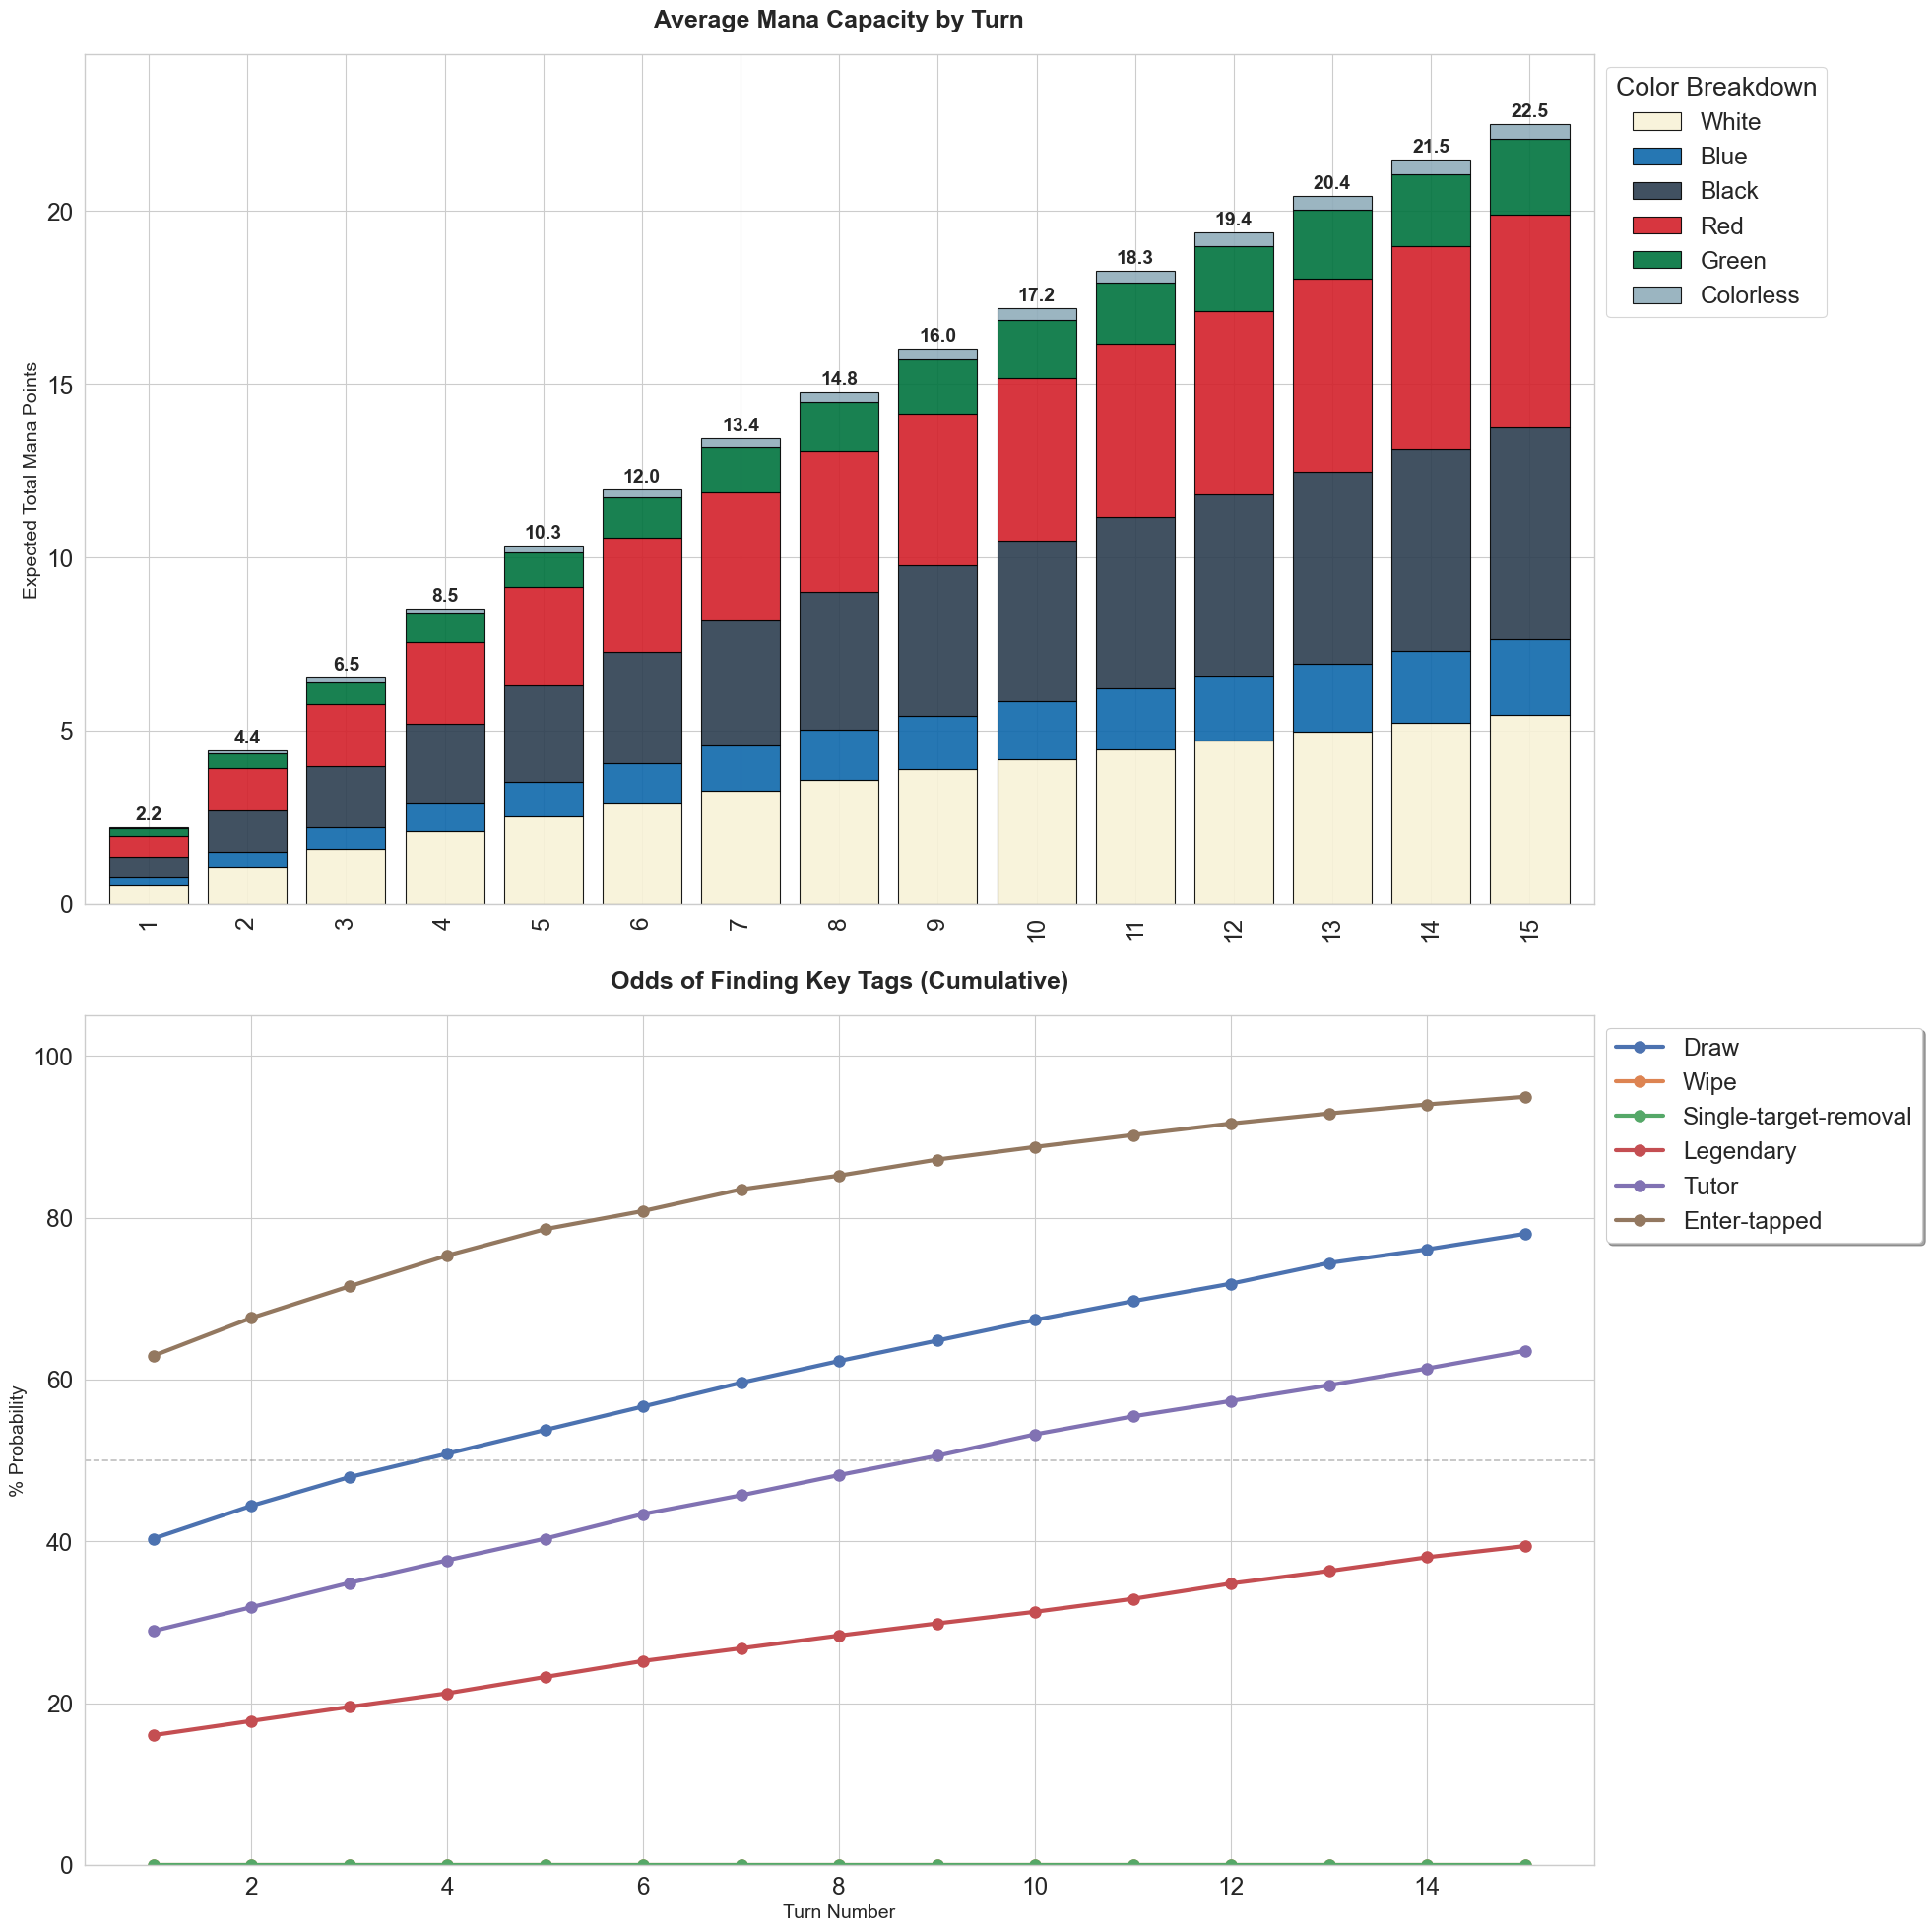

In [106]:
# 4. CHOOSE AND SIMULATE
# 'draw' is automatically available if you have numbers in the card_draw column
tags_to_graph = ['draw', 'wipe', 'single-target-removal', 'legendary', 'tutor', 'enter-tapped'] 

results = sim.run_simulation(iterations=5000, max_turns=15, tags_to_track=tags_to_graph)

# 5. VISUALIZE
plot_results(results)